# 이벤트 기반 ML 분석 노트북
## 누적 master 데이터 기반 분석 전용

**목표**: 누적 저장된 뉴스와 가격 데이터를 바탕으로 테마, lead-lag, 다중 horizon 예측을 수행

**권장 사용법**: 평소에는 이 노트북만 실행


# 빠른 사용 요약
1. 이 노트북은 기본적으로 `master CSV`만 읽고 API를 다시 호출하지 않습니다.
2. 누적된 뉴스와 가격 데이터로 테마, lead-lag, 5/20/60일 예측을 수행합니다.
3. 새 데이터를 모은 날에는 먼저 `1_data_collection.ipynb`를 실행한 뒤 이 노트북을 실행합니다.


# 1. 필수 라이브러리 설치 및 임포트

In [53]:
import os
import re
import json
import warnings
import time
import threading
from pathlib import Path
from queue import Empty
from datetime import datetime, timedelta, timezone
from multiprocessing import Manager

import numpy as np
import pandas as pd
import requests
import yfinance as yf
import hashlib

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

warnings.filterwarnings("ignore")
rcParams["font.family"] = "DejaVu Sans"
sns.set_style("whitegrid")

print("Imports loaded")


Imports loaded


# 2. 분석 설정 및 master 데이터 경로

- 이 노트북은 live API를 호출하지 않고 누적된 `master CSV`만 읽습니다.
- 데이터가 부족하면 먼저 `1_data_collection.ipynb`를 실행하세요.


In [54]:
ANALYSIS_DATE = datetime.now(timezone.utc).replace(hour=0, minute=0, second=0, microsecond=0)
LOOKBACK_DAYS = 730
FORECAST_HORIZONS = [5, 20, 60]
PRIMARY_FORECAST_HORIZON = 20
MIN_TRAIN_ROWS = 120
MIN_NEWS_HISTORY_DAYS = 45
ALLOW_WEAK_MODEL_RECOMMENDATIONS = False

# 저장 루트
WORKSPACE_ROOT = Path.cwd()
if (WORKSPACE_ROOT / "1_data_collection.ipynb").exists() or (WORKSPACE_ROOT / "2_ML_analysis.ipynb").exists():
    STOCK_ANALYSIS_DIR = WORKSPACE_ROOT
elif (WORKSPACE_ROOT / "Stock_analysis" / "1_data_collection.ipynb").exists() or (WORKSPACE_ROOT / "Stock_analysis" / "2_ML_analysis.ipynb").exists():
    STOCK_ANALYSIS_DIR = WORKSPACE_ROOT / "Stock_analysis"
else:
    STOCK_ANALYSIS_DIR = WORKSPACE_ROOT / "Stock_analysis"

# ?? ??
DATA_DIR = STOCK_ANALYSIS_DIR / "data" / "event_driven_stock_predictor"
DATA_DIR.mkdir(parents=True, exist_ok=True)

NEWS_SNAPSHOT_DIR = DATA_DIR / "news_snapshots"
PRICE_SNAPSHOT_DIR = DATA_DIR / "price_snapshots"
NEWS_MASTER_PATH = DATA_DIR / "news_master_history.csv"
PRICE_MASTER_PATH = DATA_DIR / "price_master_history.csv"

NEWS_COLUMNS = ["date", "keyword", "title", "description", "source", "url", "risk_score", "article_id", "title_key"]
PRICE_COLUMNS = [
    "date", "close", "volume", "symbol", "asset_name", "category", "kind",
    "return_1d", "vol_20d", "mom_5d", "mom_20d", "volume_chg_5d"
]

COMMODITIES = {}

STOCKS = {
    "Market_Benchmark": ["SPY", "QQQ"],
    "Semiconductor": ["SOXX", "NVDA"],
    "Defense_Aerospace": ["ITA", "LMT"],
    "Airlines": ["JETS", "DAL"],
    "Oil_Energy": ["XLE", "XOM"],
    "Coal": ["BTU"],
    "LNG_Gas": ["LNG", "EQT"],
    "Shipbuilding": ["HII"],
    "Industrials": ["XLI", "GE"],
    "Trade_Logistics": ["IYT", "UPS"],
    "Banks": ["XLF", "JPM"],
    "Gold_Miners": ["GDX", "NEM"],
    "Rare_Earths": ["MP"],
    "Lithium": ["ALB"],
}

CATEGORY_LABELS = {
    "Market_Benchmark": "미국 대표지수",
    "Semiconductor": "반도체",
    "Defense_Aerospace": "방산/항공우주",
    "Airlines": "항공",
    "Oil_Energy": "석유/에너지",
    "Coal": "석탄",
    "LNG_Gas": "LNG/천연가스",
    "Shipbuilding": "조선",
    "Industrials": "제조/산업재",
    "Trade_Logistics": "물류/운송",
    "Banks": "은행",
    "Gold_Miners": "금 관련주",
    "Rare_Earths": "희토류",
    "Lithium": "리튬",
}

ASSET_LABELS = {
    "SPY": "미국 대형주 ETF(S&P 500)",
    "QQQ": "미국 기술주 ETF(나스닥 100)",
    "SOXX": "반도체 ETF",
    "NVDA": "엔비디아(AI 반도체)",
    "ITA": "미국 방산 ETF",
    "LMT": "록히드마틴(방산)",
    "JETS": "항공 ETF",
    "DAL": "델타항공",
    "XLE": "에너지 ETF",
    "XOM": "엑슨모빌",
    "BTU": "피바디 에너지(석탄)",
    "LNG": "셰니에르 에너지(LNG)",
    "EQT": "EQT(천연가스 생산)",
    "HII": "헌팅턴 잉걸스(조선)",
    "XLI": "산업재 ETF",
    "GE": "GE 에어로스페이스",
    "IYT": "미국 운송 ETF",
    "UPS": "UPS(물류)",
    "XLF": "금융 ETF",
    "JPM": "JP모건",
    "GDX": "금광주 ETF",
    "NEM": "뉴몬트(금광)",
    "MP": "MP 머티리얼즈(희토류)",
    "ALB": "앨버말(리튬)",
}

CURRENT_PRICE_SYMBOLS = set(COMMODITIES.values()) | {s for syms in STOCKS.values() for s in syms}

EVENT_TOPICS = {
    "Geopolitical": [
        "middle east shipping",
        "red sea shipping",
        "middle east tanker attacks",
        "iran sanctions",
        "iran oil exports",
        "iran strait of hormuz",
        "israel gaza ceasefire",
        "israel iran escalation",
        "russia ukraine energy",
        "russia oil sanctions",
        "black sea shipping",
        "opec supply disruption",
        "suez canal disruption",
        "shipping insurance rates",
        "energy infrastructure attack",
        "strategic petroleum reserve release",
        "sanctions enforcement shipping",
    ],
    "Macro": [
        "fed rate cut",
        "fed rate hike",
        "fed dot plot",
        "treasury yield",
        "yield curve inversion",
        "us cpi inflation",
        "core inflation",
        "pce inflation",
        "inflation expectations",
        "labor market slowdown",
        "nonfarm payrolls surprise",
        "unemployment claims",
        "consumer spending slowdown",
        "retail sales slowdown",
        "recession risk",
        "dollar strength",
        "usd funding stress",
    ],
    "Supply_Chain_Commodity": [
        "opec+ production",
        "opec output",
        "saudi oil production",
        "saudi oil exports",
        "crude oil inventory",
        "oil refinery outages",
        "refining margins",
        "diesel crack spread",
        "lng supply",
        "natural gas storage",
        "europe gas supply",
        "europe gas storage",
        "copper demand china",
        "copper mine disruption",
        "copper smelter cuts",
        "gold safe haven demand",
        "bulk shipping demand",
        "dry bulk shipping",
        "container shipping rates",
        "freight rate surge",
        "port congestion",
        "rail freight disruption",
        "steel demand china",
    ],
    "Tech_Regulation": [
        "semiconductor export controls",
        "ai chip demand",
        "gpu supply constraints",
        "data center capex",
        "hyperscaler capex",
        "cloud spending growth",
        "taiwan semiconductor",
        "chip equipment restrictions",
        "advanced packaging capacity",
        "hbm memory demand",
        "dram pricing",
        "nand pricing",
        "foundry utilization",
        "ai inference demand",
        "ai model training spend",
        "enterprise ai adoption",
        "data center power demand",
        "grid power demand data center",
        "server supply chain",
        "semiconductor inventory correction",
        "chip lead times",
    ],
    "Financial_Stress": [
        "credit spreads widening",
        "investment grade spreads",
        "high yield spreads",
        "high yield default",
        "distressed debt",
        "commercial real estate stress",
        "office vacancy crisis",
        "bank liquidity stress",
        "regional bank stress",
        "deposit outflows",
        "private credit stress",
        "leveraged loan defaults",
        "lbo financing stress",
        "funding market stress",
        "repo market stress",
        "treasury auction weak demand",
        "sovereign downgrade",
        "debt ceiling standoff",
        "swap spread widening",
        "money market stress",
    ],
}

POSITIVE_RISK_WORDS = [
    "war", "conflict", "crisis", "attack", "explosion", "sanctions", "embargo", "blockade",
    "disruption", "shortage", "recession", "default", "bank stress", "liquidity", "downgrade",
]

def load_history_csv(path: Path, empty_columns=None):
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame(columns=empty_columns or [])

def _latest_snapshot_path(snapshot_dir: Path, prefix: str):
    files = sorted(snapshot_dir.glob(f"{prefix}_*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
    return files[0] if files else None

def load_latest_snapshot_df(snapshot_dir: Path, prefix: str, empty_columns=None):
    files = sorted(snapshot_dir.glob(f"{prefix}_*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        return pd.DataFrame(columns=empty_columns or [])
    return pd.read_csv(files[0])

def _normalize_url(value):
    raw = str(value).strip()
    if not raw or raw.lower() == "nan":
        return ""
    return re.sub(r"[?#].*$", "", raw.lower())

def _normalize_title(value):
    text = str(value or "").strip().lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def _article_id_from_row(row):
    normalized_url = _normalize_url(row.get("url", ""))
    if normalized_url:
        return hashlib.sha256(normalized_url.encode("utf-8")).hexdigest()
    title_key = _normalize_title(row.get("title", ""))
    source = str(row.get("source", "") or "").strip().lower()
    keyword = str(row.get("keyword", "") or "").strip().lower()
    date_part = pd.to_datetime(row.get("date"), utc=True, errors="coerce")
    date_part = date_part.strftime("%Y-%m-%d") if pd.notna(date_part) else ""
    payload = f"{title_key}|{source}|{keyword}|{date_part}"
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()

def prepare_news_history(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame(columns=NEWS_COLUMNS)
    base = df.copy()
    for c in NEWS_COLUMNS:
        if c not in base.columns:
            base[c] = np.nan
    base["date"] = pd.to_datetime(base["date"], utc=True, errors="coerce")
    base = base.dropna(subset=["date"])
    for c in ["keyword", "title", "description", "source", "url"]:
        base[c] = base[c].fillna("").astype(str).str.strip()
    base["risk_score"] = pd.to_numeric(base["risk_score"], errors="coerce").fillna(0.0).clip(0, 1)
    base["title_key"] = base["title"].map(_normalize_title)
    base["article_id"] = base.apply(_article_id_from_row, axis=1)
    base["publish_day"] = base["date"].dt.floor("D")
    base = base.sort_values(["date", "article_id"])
    base = base.drop_duplicates(subset=["article_id"], keep="last")
    base = base.drop_duplicates(subset=["title_key", "source", "publish_day"], keep="last")
    return base[NEWS_COLUMNS].reset_index(drop=True)

def prepare_price_history(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame(columns=PRICE_COLUMNS)
    base = df.copy()
    for c in PRICE_COLUMNS:
        if c not in base.columns:
            base[c] = np.nan
    base["date"] = pd.to_datetime(base["date"], utc=True, errors="coerce")
    numeric_cols = ["close", "volume", "return_1d", "vol_20d", "mom_5d", "mom_20d", "volume_chg_5d"]
    for c in numeric_cols:
        base[c] = pd.to_numeric(base[c], errors="coerce")
    base = base.dropna(subset=["date", "symbol", "close"])
    base = base.sort_values(["symbol", "date"]).drop_duplicates(subset=["date", "symbol"], keep="last")
    return base[PRICE_COLUMNS].reset_index(drop=True)

print(f"Analysis date: {ANALYSIS_DATE:%Y-%m-%d}")
print(f"Lookback days: {LOOKBACK_DAYS}")
print(f"Forecast horizons: {FORECAST_HORIZONS} (primary={PRIMARY_FORECAST_HORIZON}d)")
print(f"Master news path: {NEWS_MASTER_PATH}")
print(f"Master price path: {PRICE_MASTER_PATH}")
print(f"Data dir: {DATA_DIR.resolve()}")


Analysis date: 2026-03-24
Lookback days: 730
Forecast horizons: [5, 20, 60] (primary=20d)
Master news path: c:\Users\user\Documents\GitHub\GB_practicing\Stock_analysis\data\event_driven_stock_predictor\news_master_history.csv
Master price path: c:\Users\user\Documents\GitHub\GB_practicing\Stock_analysis\data\event_driven_stock_predictor\price_master_history.csv
Data dir: C:\Users\user\Documents\GitHub\GB_practicing\Stock_analysis\data\event_driven_stock_predictor


# 3. 분석 안내

- 이 노트북은 분석 전용입니다.
- `news_master_history.csv`, `price_master_history.csv`를 바탕으로 테마, lead-lag, 예측을 수행합니다.


In [55]:
print("Analysis notebook guide")
print(f"- NEWS_MASTER_PATH: {NEWS_MASTER_PATH}")
print(f"- PRICE_MASTER_PATH: {PRICE_MASTER_PATH}")
print("- This notebook does not call live news or price APIs.")


Analysis notebook guide
- NEWS_MASTER_PATH: c:\Users\user\Documents\GitHub\GB_practicing\Stock_analysis\data\event_driven_stock_predictor\news_master_history.csv
- PRICE_MASTER_PATH: c:\Users\user\Documents\GitHub\GB_practicing\Stock_analysis\data\event_driven_stock_predictor\price_master_history.csv
- This notebook does not call live news or price APIs.


# 4. 실행 순서

1. 이 노트북을 그대로 실행
2. 추천 게이트가 닫혀 있으면 `1_data_collection.ipynb`에서 데이터 추가 수집
3. 다시 이 노트북을 실행


# 5. 뉴스 master 로드

- 누적된 `news_master_history.csv`를 읽고 일별 뉴스 특성으로 요약합니다.


In [56]:
def _safe_text(value):
    return str(value) if value is not None else ""

def _risk_score_from_text(title, description):
    text = f"{_safe_text(title)} {_safe_text(description)}".lower()
    hits = sum(1 for w in POSITIVE_RISK_WORDS if w in text)
    return min(hits / max(len(POSITIVE_RISK_WORDS), 1), 1.0)

def build_daily_news_features(news_df, analysis_date):
    date_index = pd.date_range(analysis_date - timedelta(days=LOOKBACK_DAYS), analysis_date, freq="D", tz="UTC")
    full = pd.DataFrame({"date": date_index})
    if news_df is None or news_df.empty:
        empty = full.copy()
        empty["news_count"] = 0
        empty["source_count"] = 0
        empty["keyword_count"] = 0
        empty["avg_risk"] = 0.0
        empty["max_risk"] = 0.0
        empty["has_news"] = 0
        empty["news_count_7d"] = 0.0
        empty["avg_risk_7d"] = 0.0
        for kw in ["oil", "war", "sanctions", "china", "taiwan", "inflation"]:
            empty[f"kw_{kw}"] = 0.0
        for theme in EVENT_TOPICS:
            empty[f"theme_{theme.lower()}"] = 0.0
        return empty
    df = prepare_news_history(news_df)
    df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce").dt.floor("D")
    df = df.dropna(subset=["date"])
    df["title_desc"] = (df["title"].fillna("") + " " + df["description"].fillna("")).str.lower()
    daily = df.groupby("date").agg(news_count=("title", "count"), source_count=("source", "nunique"), keyword_count=("keyword", "nunique"), avg_risk=("risk_score", "mean"), max_risk=("risk_score", "max")).reset_index()
    daily["has_news"] = (daily["news_count"] > 0).astype(int)
    for kw in ["oil", "war", "sanctions", "china", "taiwan", "inflation"]:
        tmp = df.assign(hit=df["title_desc"].str.contains(kw, regex=False).astype(int)).groupby("date")["hit"].sum().reset_index().rename(columns={"hit": f"kw_{kw}"})
        daily = daily.merge(tmp, on="date", how="left")
    for theme, keywords in EVENT_TOPICS.items():
        tmp = df.assign(hit=df["title_desc"].apply(lambda text: sum(1 for kw in keywords if kw in text))).groupby("date")["hit"].sum().reset_index().rename(columns={"hit": f"theme_{theme.lower()}"})
        daily = daily.merge(tmp, on="date", how="left")
    daily = full.merge(daily, on="date", how="left").fillna(0)
    daily["news_count_7d"] = daily["news_count"].rolling(7, min_periods=1).sum()
    daily["avg_risk_7d"] = daily["avg_risk"].rolling(7, min_periods=1).mean()
    return daily

df_news = prepare_news_history(load_history_csv(NEWS_MASTER_PATH, empty_columns=NEWS_COLUMNS))
if df_news.empty:
    df_news = prepare_news_history(load_latest_snapshot_df(NEWS_SNAPSHOT_DIR, "news_history", empty_columns=NEWS_COLUMNS))
news_cutoff = ANALYSIS_DATE - timedelta(days=LOOKBACK_DAYS)
df_news = df_news[df_news["date"] >= news_cutoff].copy() if len(df_news) > 0 else df_news
daily_news = build_daily_news_features(df_news, ANALYSIS_DATE)
print(f"News rows loaded: {len(df_news)}")
print(f"Daily news rows: {len(daily_news)}")


News rows loaded: 1728
Daily news rows: 731


# 6. 가격 master 로드

- 누적된 `price_master_history.csv`를 읽고 분석 용 시계열로 정리합니다.


In [57]:
df_prices = prepare_price_history(load_history_csv(PRICE_MASTER_PATH, empty_columns=PRICE_COLUMNS))
if df_prices.empty:
    df_prices = prepare_price_history(load_latest_snapshot_df(PRICE_SNAPSHOT_DIR, "price_history", empty_columns=PRICE_COLUMNS))
if len(df_prices) > 0:
    df_prices = df_prices[df_prices["symbol"].isin(CURRENT_PRICE_SYMBOLS)].copy()
price_cutoff = ANALYSIS_DATE - timedelta(days=LOOKBACK_DAYS)
df_prices = df_prices[df_prices["date"] >= price_cutoff].copy() if len(df_prices) > 0 else df_prices
price_symbol_count = df_prices["symbol"].nunique() if not df_prices.empty else 0
print(f"Price rows loaded: {len(df_prices)}")
print(f"Price symbols loaded: {price_symbol_count}")


Price rows loaded: 12000
Price symbols loaded: 24


# 7. 데이터 전처리 및 특성 엔지니어링


In [58]:
# 최신 master/snapshot 강제 재로딩 (중간 셀만 실행해도 일관성 유지)
df_news = prepare_news_history(load_history_csv(NEWS_MASTER_PATH, empty_columns=NEWS_COLUMNS))
if len(df_news) > 0:
    news_cutoff = ANALYSIS_DATE - timedelta(days=LOOKBACK_DAYS)
    df_news = df_news[df_news["date"] >= news_cutoff].copy()
daily_news = build_daily_news_features(df_news, ANALYSIS_DATE)
df_prices = prepare_price_history(load_history_csv(PRICE_MASTER_PATH, empty_columns=PRICE_COLUMNS))
if df_prices.empty:
    df_prices = prepare_price_history(load_latest_snapshot_df(PRICE_SNAPSHOT_DIR, "price_history", empty_columns=PRICE_COLUMNS))
if len(df_prices) > 0:
    df_prices = df_prices[df_prices["symbol"].isin(CURRENT_PRICE_SYMBOLS)].copy()

def compute_lead_lag(event_daily, price_daily, max_lag=7):
    if event_daily.empty or price_daily.empty:
        return pd.DataFrame(columns=["symbol", "best_lag", "best_corr"])
    e = event_daily[["date", "avg_risk_7d"]].copy()
    e["date"] = pd.to_datetime(e["date"], utc=True).dt.tz_localize(None)
    results = []
    for sym, sdf in price_daily.groupby("symbol"):
        s = sdf[["date", "return_1d"]].dropna().copy()
        if len(s) < 30:
            continue
        s["date"] = pd.to_datetime(s["date"], utc=True).dt.tz_localize(None)
        merged = s.merge(e, on="date", how="left")
        merged["avg_risk_7d"] = pd.to_numeric(merged["avg_risk_7d"], errors="coerce").fillna(0.0)
        best_lag = 0
        best_corr = 0.0
        for lag in range(-max_lag, max_lag + 1):
            shifted = merged["avg_risk_7d"].shift(lag)
            corr = merged["return_1d"].corr(shifted)
            if pd.notna(corr) and abs(corr) > abs(best_corr):
                best_corr = float(corr)
                best_lag = lag
        results.append({"symbol": sym, "best_lag": best_lag, "best_corr": best_corr})
    return pd.DataFrame(results).sort_values("best_corr", key=np.abs, ascending=False)

df_lead_lag = compute_lead_lag(daily_news, df_prices, max_lag=7)
print("Lead-lag sample:")
print(df_lead_lag.head(10))

def create_model_dataset(df_prices, daily_news, horizons=None):
    horizons = horizons or FORECAST_HORIZONS
    if df_prices.empty:
        return pd.DataFrame()
    base = df_prices.copy()
    base["date"] = pd.to_datetime(base["date"], utc=True).dt.floor("D")
    news = daily_news.copy()
    news["date"] = pd.to_datetime(news["date"], utc=True).dt.floor("D")
    merged = base.merge(news, on="date", how="left")
    merged = merged.sort_values(["symbol", "date"]).reset_index(drop=True)
    zero_fill_cols = [c for c in merged.columns if c not in ["date", "symbol", "asset_name", "category", "kind"]]
    for c in zero_fill_cols:
        merged[c] = pd.to_numeric(merged[c], errors="coerce").fillna(0.0)
    g = merged.groupby("symbol", group_keys=False)
    merged["ret_lag1"] = g["return_1d"].shift(1)
    merged["ret_lag3"] = g["return_1d"].rolling(3).mean().reset_index(level=0, drop=True)
    merged["ret_lag10"] = g["return_1d"].rolling(10).mean().reset_index(level=0, drop=True)
    merged["vol_lag10"] = g["return_1d"].rolling(10).std().reset_index(level=0, drop=True)
    merged["price_low_20d"] = g["close"].rolling(20).min().reset_index(level=0, drop=True)
    merged["price_low_60d"] = g["close"].rolling(60).min().reset_index(level=0, drop=True)
    merged["price_high_20d"] = g["close"].rolling(20).max().reset_index(level=0, drop=True)
    merged["price_high_60d"] = g["close"].rolling(60).max().reset_index(level=0, drop=True)
    close_now = pd.to_numeric(merged["close"], errors="coerce").replace(0, np.nan)
    merged["drawdown_20d"] = close_now.div(merged["price_high_20d"].replace(0, np.nan)) - 1.0
    merged["drawdown_60d"] = close_now.div(merged["price_high_60d"].replace(0, np.nan)) - 1.0
    merged["rebound_from_20d_low"] = close_now.div(merged["price_low_20d"].replace(0, np.nan)) - 1.0
    merged["rebound_from_60d_low"] = close_now.div(merged["price_low_60d"].replace(0, np.nan)) - 1.0
    merged["shock_5d"] = g["close"].transform(lambda s: s.div(s.shift(5).replace(0, np.nan)) - 1.0)
    merged["shock_20d"] = g["close"].transform(lambda s: s.div(s.shift(20).replace(0, np.nan)) - 1.0)
    merged["oversold_rebound_score"] = (-merged["drawdown_20d"].clip(upper=0).fillna(0.0) * (1.0 + merged["rebound_from_20d_low"].fillna(0.0))).clip(lower=0.0)
    for horizon in horizons:
        future_close = g["close"].shift(-horizon)
        merged[f"target_return_{horizon}d"] = future_close.div(close_now) - 1.0
        merged[f"target_up_{horizon}d"] = (merged[f"target_return_{horizon}d"] > 0).astype(int)
    feature_cols = [
        "news_count", "source_count", "keyword_count", "avg_risk", "max_risk", "has_news",
        "news_count_7d", "avg_risk_7d", "kw_oil", "kw_war", "kw_sanctions", "kw_china", "kw_taiwan", "kw_inflation",
        "theme_geopolitical", "theme_macro", "theme_supply_chain_commodity", "theme_tech_regulation", "theme_financial_stress",
        "return_1d", "vol_20d", "mom_5d", "mom_20d", "volume_chg_5d", "ret_lag1", "ret_lag3", "ret_lag10", "vol_lag10",
        "drawdown_20d", "drawdown_60d", "rebound_from_20d_low", "rebound_from_60d_low", "shock_5d", "shock_20d", "oversold_rebound_score",
    ]
    for c in feature_cols:
        if c not in merged.columns:
            merged[c] = 0.0
    target_cols = []
    for horizon in horizons:
        target_cols.extend([f"target_return_{horizon}d", f"target_up_{horizon}d"])
    cols = ["date", "symbol", "asset_name", "category", "kind"] + target_cols + feature_cols
    ds = merged[cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    primary_target_col = f"target_return_{PRIMARY_FORECAST_HORIZON}d"
    ds = ds.dropna(subset=[primary_target_col])
    return ds

df_features = create_model_dataset(df_prices, daily_news, horizons=FORECAST_HORIZONS)
print(f"Model dataset rows: {len(df_features)}")
print(f"Symbols in dataset: {df_features['symbol'].nunique() if len(df_features)>0 else 0}")
if len(df_features) > 0:
    print(df_features.head(3))
print("Diagnostics")
if len(df_news) == 0:
    print("- News master history empty. Keep collecting over time.")
else:
    news_dates = pd.to_datetime(df_news["date"], utc=True, errors="coerce").dropna()
    print(f"- News date range: {news_dates.min()} -> {news_dates.max()}")
    print(f"- News unique sources: {df_news['source'].replace('', np.nan).dropna().nunique()}")
    print(f"- News covered days: {daily_news['has_news'].sum():.0f}")
if len(df_prices) == 0:
    print("- Price history empty.")
else:
    min_rows = df_prices.groupby("symbol").size().min()
    print(f"- Price symbols: {df_prices['symbol'].nunique()}, min rows per symbol: {int(min_rows)}")


Lead-lag sample:
   symbol  best_lag  best_corr
4     GDX        -1  -0.174180
12    LNG        -2   0.165155
14    NEM        -1  -0.140523
9    JETS        -1  -0.120181
19    UPS        -1  -0.112082
7     ITA         5  -0.111434
5      GE        -1  -0.108452
22    XLI        -1  -0.107209
8     IYT        -1  -0.089573
21    XLF        -7  -0.081658
Model dataset rows: 12024
Symbols in dataset: 24
                       date symbol asset_name category   kind  \
0 2024-03-22 00:00:00+00:00    ALB    앨버말(리튬)  Lithium  stock   
1 2024-03-25 00:00:00+00:00    ALB    앨버말(리튬)  Lithium  stock   
2 2024-03-26 00:00:00+00:00    ALB    앨버말(리튬)  Lithium  stock   

   target_return_5d  target_up_5d  target_return_20d  target_up_20d  \
0          0.068840             1          -0.070908              0   
1          0.068695             1          -0.034981              0   
2          0.082850             1          -0.031426              0   

   target_return_60d  ...  ret_lag3  ret_lag10 

# 8. 현재 이벤트 확률 분석


In [59]:
def assess_current_event_themes(df_news, analysis_date):
    themes = {
        "Energy Supply Shock": ["oil", "gas", "pipeline", "embargo", "opec"],
        "Geopolitical Conflict": ["war", "conflict", "military", "attack", "sanctions"],
        "China-Taiwan Tension": ["china", "taiwan", "strait", "semiconductor", "chip"],
        "Macro Stress": ["inflation", "interest rate", "recession", "fed", "cpi"],
    }

    if df_news.empty:
        return pd.DataFrame([{"Theme": k, "Probability": 0.1} for k in themes])

    recent_cut = analysis_date - timedelta(days=30)
    recent = df_news[pd.to_datetime(df_news["date"], utc=True) >= recent_cut].copy()
    recent["text"] = (recent["title"].fillna("") + " " + recent["description"].fillna("")).str.lower()
    if recent.empty:
        return pd.DataFrame([{"Theme": k, "Probability": 0.1} for k in themes])

    rows = []
    for theme, kws in themes.items():
        hits = 0
        for kw in kws:
            hits += recent["text"].str.contains(re.escape(kw), regex=True).sum()
        freq = min(hits / max(len(recent), 1), 1.0)
        avg_risk = recent.loc[recent["text"].str.contains("|".join(map(re.escape, kws)), regex=True), "risk_score"]
        risk = float(avg_risk.mean()) if len(avg_risk) > 0 else 0.0
        prob = float(np.clip(0.65 * risk + 0.35 * freq, 0.05, 0.95))
        rows.append({"Theme": theme, "Probability": prob})

    return pd.DataFrame(rows).sort_values("Probability", ascending=False)


df_threats = assess_current_event_themes(df_news, ANALYSIS_DATE)
print("Current issue probabilities:")
print(df_threats)


Current issue probabilities:
                   Theme  Probability
1  Geopolitical Conflict     0.300924
0    Energy Supply Shock     0.210070
2   China-Taiwan Tension     0.146093
3           Macro Stress     0.126550


# 9. 이벤트 기반 주식 가격 예측


In [60]:
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from joblib import Parallel, delayed

N_WORKERS = -1
PARAM_LOG_EVERY = 6
ETA_PROBE_PARAMS = 3
RF_CV_FOLDS = 5
RF_PROGRESS_EVERY_FOLDS = 10
RF_PROGRESS_HEARTBEAT_SEC = 15
RF_ETA_WARMUP_RATIO = 0.05
RF_ETA_WINDOW = 200
MIN_ACCEPTABLE_CV_R2 = 0.0
MIN_ACCEPTABLE_HOLDOUT_R2 = -0.05
MIN_ACCEPTABLE_UP_ACC = 0.53
MIN_PREDICTION_CONFIDENCE = 0.35
PRIMARY_TARGET_RETURN_COL = f"target_return_{PRIMARY_FORECAST_HORIZON}d"
PRIMARY_TARGET_UP_COL = f"target_up_{PRIMARY_FORECAST_HORIZON}d"

def _calc_confidence(cv_r2_mean, cv_mae_mean, up_acc_cv_mean):
    r2_part = max(cv_r2_mean, 0.0) * 0.45
    mae_part = (1.0 - min(cv_mae_mean / 0.06, 1.0)) * 0.35
    cls_part = up_acc_cv_mean * 0.20
    return float(np.clip(r2_part + mae_part + cls_part, 0.0, 1.0))

def _best_rf_regressor_with_tscv(X, y, random_state=42, symbol=None, horizon=None, progress_queue=None):
    param_grid = {
        "n_estimators": [300, 600],
        "max_depth": [None, 12, 20],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", 0.7],
    }
    param_list = list(ParameterGrid(param_grid))
    total_params = len(param_list)
    run_label = f"horizon={horizon or '?'}"
    search_start = time.perf_counter()
    print(f"[RF search start] {run_label} | params={total_params} | folds={RF_CV_FOLDS}", flush=True)
    tscv = TimeSeriesSplit(n_splits=RF_CV_FOLDS)
    best = None
    best_score = -np.inf
    for param_idx, p in enumerate(param_list, start=1):
        fold_r2, fold_mae = [], []
        for tr_idx, va_idx in tscv.split(X):
            X_tr, X_va = X[tr_idx], X[va_idx]
            y_tr, y_va = y[tr_idx], y[va_idx]
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr)
            X_va_sc = scaler.transform(X_va)
            reg = RandomForestRegressor(n_estimators=p["n_estimators"], max_depth=p["max_depth"], min_samples_leaf=p["min_samples_leaf"], max_features=p["max_features"], random_state=random_state, n_jobs=1)
            reg.fit(X_tr_sc, y_tr)
            y_hat = reg.predict(X_va_sc)
            if progress_queue is not None:
                progress_queue.put({"event": "rf_fold", "horizon": horizon or '?'})
            fold_r2.append(r2_score(y_va, y_hat))
            fold_mae.append(mean_absolute_error(y_va, y_hat))
        r2_mean = float(np.mean(fold_r2))
        mae_mean = float(np.mean(fold_mae))
        score = r2_mean - 0.25 * mae_mean
        if score > best_score:
            best_score = score
            best = {"params": p, "cv_r2_mean": r2_mean, "cv_mae_mean": mae_mean}
        if param_idx == 1 or param_idx % PARAM_LOG_EVERY == 0 or param_idx == total_params:
            elapsed = time.perf_counter() - search_start
            avg_per_param = elapsed / param_idx if param_idx else np.nan
            eta_seconds = avg_per_param * (total_params - param_idx) if param_idx >= 2 else None
            finish_at = (datetime.now() + timedelta(seconds=eta_seconds)).strftime("%H:%M:%S") if eta_seconds is not None else "estimating..."
            print(f"[RF search] {run_label} | {param_idx}/{total_params} params | elapsed {_format_eta(elapsed)} | ETA {_format_eta(eta_seconds)} | finish ~ {finish_at} | best_score={best_score:.4f}", flush=True)
    total_elapsed = time.perf_counter() - search_start
    print(f"[RF search done] {run_label} | elapsed {_format_eta(total_elapsed)} | best_params={best['params'] if best else None}", flush=True)
    return best

def _positive_class_proba(clf, X):
    probs = clf.predict_proba(X)
    classes = list(getattr(clf, "classes_", []))
    if 1 in classes:
        return probs[:, classes.index(1)]
    if 0 in classes:
        return np.zeros(len(X), dtype=float)
    return np.full(len(X), 0.5, dtype=float)

def _cv_up_accuracy(X, y_up, random_state=42):
    tscv = TimeSeriesSplit(n_splits=RF_CV_FOLDS)
    fold_acc = []
    for tr_idx, va_idx in tscv.split(X):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y_up[tr_idx], y_up[va_idx]
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_va_sc = scaler.transform(X_va)
        clf = RandomForestClassifier(n_estimators=400, min_samples_leaf=2, random_state=random_state, n_jobs=1)
        clf.fit(X_tr_sc, y_tr)
        y_hat = (_positive_class_proba(clf, X_va_sc) >= 0.5).astype(int)
        fold_acc.append(accuracy_score(y_va, y_hat))
    return float(np.mean(fold_acc))

def _theme_alignment_score(category, df_threats):
    if df_threats is None or len(df_threats) == 0:
        return 1.0
    category = str(category)
    theme_probs = dict(zip(df_threats["Theme"], df_threats["Probability"]))
    boosts = []
    if category in ["Oil_Energy", "Coal", "LNG_Gas"]:
        boosts.append(theme_probs.get("Energy Supply Shock", 0.0))
    if category in ["Defense_Aerospace", "Shipbuilding", "Gold_Miners", "Oil_Energy"]:
        boosts.append(theme_probs.get("Geopolitical Conflict", 0.0))
    if category in ["Semiconductor", "Rare_Earths", "Lithium"]:
        boosts.append(theme_probs.get("China-Taiwan Tension", 0.0))
    if category in ["Market_Benchmark", "Banks", "Industrials", "Trade_Logistics", "Airlines", "Gold_Miners"]:
        boosts.append(theme_probs.get("Macro Stress", 0.0))
    if not boosts:
        return 1.0
    return float(1.0 + np.mean(boosts) * 0.05)

def _fit_one_horizon(sdf, feature_cols, target_return_col, target_up_col, random_state=42, symbol=None, horizon=None, progress_queue=None):
    usable = sdf.dropna(subset=[target_return_col]).sort_values("date").reset_index(drop=True)
    if len(usable) < max(MIN_TRAIN_ROWS, 160):
        return None
    horizon_label = f"horizon={horizon or '?'}"
    horizon_start = time.perf_counter()
    print(f"[Horizon start] {horizon_label} | rows={len(usable)}", flush=True)
    split = int(len(usable) * 0.8)
    train, test = usable.iloc[:split], usable.iloc[split:]
    if len(test) < 30:
        return None
    X_train = train[feature_cols].values
    y_train = train[target_return_col].values
    X_test = test[feature_cols].values
    y_test = test[target_return_col].values
    best = _best_rf_regressor_with_tscv(X_train, y_train, random_state=random_state, symbol=symbol, horizon=horizon, progress_queue=progress_queue)
    if best is None:
        return None
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)
    reg = RandomForestRegressor(**best["params"], random_state=random_state, n_jobs=1)
    reg.fit(X_train_sc, y_train)
    y_pred = reg.predict(X_test_sc)
    holdout_mae = float(mean_absolute_error(y_test, y_pred))
    holdout_r2 = float(r2_score(y_test, y_pred))
    y_train_up = train[target_up_col].values.astype(int)
    y_test_up = test[target_up_col].values.astype(int)
    clf = RandomForestClassifier(n_estimators=450, min_samples_leaf=2, random_state=random_state, n_jobs=1)
    clf.fit(X_train_sc, y_train_up)
    holdout_up_acc = float(accuracy_score(y_test_up, (_positive_class_proba(clf, X_test_sc) >= 0.5).astype(int)))
    cv_up_acc = _cv_up_accuracy(X_train, y_train_up, random_state=random_state)
    latest_row = usable.iloc[-1]
    X_latest = scaler.transform(latest_row[feature_cols].values.reshape(1, -1))
    pred_return = float(reg.predict(X_latest)[0])
    pred_up_prob = float(_positive_class_proba(clf, X_latest)[0])
    confidence = _calc_confidence(best["cv_r2_mean"], best["cv_mae_mean"], cv_up_acc)
    fi = pd.Series(reg.feature_importances_, index=feature_cols).sort_values(ascending=False)
    horizon_elapsed = time.perf_counter() - horizon_start
    print(f"[Horizon done] {horizon_label} | elapsed {_format_eta(horizon_elapsed)} | cv_r2={best['cv_r2_mean']:.4f} | holdout_r2={holdout_r2:.4f}", flush=True)
    return {
        "pred_return": pred_return,
        "pred_up_prob": pred_up_prob,
        "confidence": confidence,
        "cv_r2": float(best["cv_r2_mean"]),
        "cv_mae": float(best["cv_mae_mean"]),
        "cv_up_acc": float(cv_up_acc),
        "holdout_r2": holdout_r2,
        "holdout_mae": holdout_mae,
        "holdout_up_acc": holdout_up_acc,
        "top_drivers": ", ".join(fi.head(5).index.tolist()),
        "rows": int(len(usable)),
        "best_params": str(best["params"]),
    }

def _fit_one_symbol(sym, sdf, feature_cols, df_threats, progress_queue=None):
    sdf = sdf.sort_values("date").reset_index(drop=True)
    if len(sdf) < max(MIN_TRAIN_ROWS, 160):
        return sym, None, None
    latest_row = sdf.iloc[-1]
    theme_multiplier = _theme_alignment_score(latest_row["category"], df_threats)
    pred_row = {
        "Stock": sym,
        "Asset_Name": latest_row.get("asset_name", ASSET_LABELS.get(sym, sym)),
        "Category": latest_row["category"],
        "Category_KR": CATEGORY_LABELS.get(latest_row["category"], latest_row["category"]),
        "Theme_Multiplier": theme_multiplier,
        "Oversold_Rebound_Score": float(latest_row.get("oversold_rebound_score", 0.0)),
        "Drawdown_20D_%": float(latest_row.get("drawdown_20d", 0.0) * 100),
        "Drawdown_60D_%": float(latest_row.get("drawdown_60d", 0.0) * 100),
    }
    eval_row = {"Stock": sym, "Asset_Name": latest_row.get("asset_name", ASSET_LABELS.get(sym, sym)), "Category": latest_row["category"], "Category_KR": CATEGORY_LABELS.get(latest_row["category"], latest_row["category"])}
    primary_result = None
    for horizon in FORECAST_HORIZONS:
        target_return_col = f"target_return_{horizon}d"
        target_up_col = f"target_up_{horizon}d"
        result = _fit_one_horizon(sdf, feature_cols, target_return_col, target_up_col, random_state=42 + horizon, symbol=sym, horizon=f"{horizon}D", progress_queue=progress_queue)
        if result is None:
            continue
        adjusted_return = result["pred_return"] * theme_multiplier
        pred_row[f"Expected_Return_{horizon}D_%"] = adjusted_return * 100
        pred_row[f"Up_Probability_{horizon}D"] = result["pred_up_prob"]
        pred_row[f"Confidence_{horizon}D"] = result["confidence"]
        eval_row[f"Rows_{horizon}D"] = result["rows"]
        eval_row[f"CV_R2_{horizon}D"] = result["cv_r2"]
        eval_row[f"CV_MAE_{horizon}D"] = result["cv_mae"]
        eval_row[f"CV_Up_Acc_{horizon}D"] = result["cv_up_acc"]
        eval_row[f"Holdout_R2_{horizon}D"] = result["holdout_r2"]
        eval_row[f"Holdout_MAE_{horizon}D"] = result["holdout_mae"]
        eval_row[f"Holdout_Up_Acc_{horizon}D"] = result["holdout_up_acc"]
        eval_row[f"Best_Params_{horizon}D"] = result["best_params"]
        if horizon == PRIMARY_FORECAST_HORIZON:
            primary_result = result
            pred_row["Expected_Return_%"] = adjusted_return * 100
            pred_row["Up_Probability"] = result["pred_up_prob"]
            pred_row["Confidence"] = result["confidence"]
            pred_row["Top_Drivers"] = result["top_drivers"]
    if primary_result is None:
        return sym, None, None
    rebound_bonus = min(max(pred_row["Oversold_Rebound_Score"], 0.0), 0.25)
    quality_pass = bool((primary_result["cv_r2"] >= MIN_ACCEPTABLE_CV_R2) and (primary_result["holdout_r2"] >= MIN_ACCEPTABLE_HOLDOUT_R2) and (primary_result["cv_up_acc"] >= MIN_ACCEPTABLE_UP_ACC) and (primary_result["confidence"] >= MIN_PREDICTION_CONFIDENCE))
    pred_row["Quality_Pass"] = quality_pass
    pred_row["Adjusted_Return_%"] = pred_row["Expected_Return_%"] * pred_row["Confidence"] * (1.0 + rebound_bonus)
    pred_row["Adjusted_Return_Prob_%"] = pred_row["Expected_Return_%"] * pred_row["Confidence"] * (0.5 + 0.5 * pred_row["Up_Probability"]) * (1.0 + rebound_bonus)
    eval_row["Quality_Pass"] = quality_pass
    eval_row["Rebound_Bonus"] = rebound_bonus
    eval_row["Primary_Horizon_Days"] = PRIMARY_FORECAST_HORIZON
    return sym, pred_row, eval_row

def _format_eta(seconds):
    if seconds is None or not np.isfinite(seconds) or seconds < 0:
        return "estimating..."
    seconds = int(round(seconds))
    hours, rem = divmod(seconds, 3600)
    minutes, secs = divmod(rem, 60)
    if hours > 0:
        return f"{hours:d}h {minutes:02d}m {secs:02d}s"
    if minutes > 0:
        return f"{minutes:d}m {secs:02d}s"
    return f"{secs:d}s"

def _estimate_total_runtime_seconds(grouped, feature_cols):
    eligible = [(sym, sdf.sort_values("date").reset_index(drop=True)) for sym, sdf in grouped if len(sdf) >= max(MIN_TRAIN_ROWS, 160)]
    if not eligible:
        return None
    eligible = sorted(eligible, key=lambda item: len(item[1]))
    probe_sym, probe_sdf = eligible[len(eligible) // 2]
    probe_horizon = FORECAST_HORIZONS[0]
    target_return_col = f"target_return_{probe_horizon}d"
    usable = probe_sdf.dropna(subset=[target_return_col]).sort_values("date").reset_index(drop=True)
    if len(usable) < max(MIN_TRAIN_ROWS, 160):
        return None
    split = int(len(usable) * 0.8)
    train = usable.iloc[:split]
    if len(usable.iloc[split:]) < 30:
        return None
    X_train = train[feature_cols].values
    y_train = train[target_return_col].values
    param_grid = {
        "n_estimators": [300, 600],
        "max_depth": [None, 12, 20],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", 0.7],
    }
    param_list = list(ParameterGrid(param_grid))
    probe_params = min(ETA_PROBE_PARAMS, len(param_list))
    print(f"[ETA probe] representative horizon={probe_horizon}D | sampled_params={probe_params}/{len(param_list)}", flush=True)
    probe_start = time.perf_counter()
    tscv = TimeSeriesSplit(n_splits=5)
    for p in param_list[:probe_params]:
        for tr_idx, va_idx in tscv.split(X_train):
            X_tr, X_va = X_train[tr_idx], X_train[va_idx]
            y_tr, y_va = y_train[tr_idx], y_train[va_idx]
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr)
            X_va_sc = scaler.transform(X_va)
            reg = RandomForestRegressor(n_estimators=p["n_estimators"], max_depth=p["max_depth"], min_samples_leaf=p["min_samples_leaf"], max_features=p["max_features"], random_state=42 + probe_horizon, n_jobs=1)
            reg.fit(X_tr_sc, y_tr)
            _ = reg.predict(X_va_sc)
    probe_elapsed = time.perf_counter() - probe_start
    avg_seconds_per_param = probe_elapsed / probe_params if probe_params else None
    if avg_seconds_per_param is None:
        return None
    estimated_search_seconds = avg_seconds_per_param * len(param_list)
    estimated_horizon_seconds = estimated_search_seconds * (187 / 180)
    effective_workers = os.cpu_count() if N_WORKERS == -1 else max(N_WORKERS, 1)
    total_seconds = estimated_horizon_seconds * len(FORECAST_HORIZONS) * len(eligible) / max(effective_workers, 1)
    finish_at = (datetime.now() + timedelta(seconds=total_seconds)).strftime("%H:%M:%S")
    print(f"[ETA probe done] estimated total runtime {_format_eta(total_seconds)} | finish ~ {finish_at}", flush=True)
    return total_seconds

def _count_total_rf_steps(grouped):
    total_params = len(list(ParameterGrid({
        "n_estimators": [300, 600],
        "max_depth": [None, 12, 20],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", 0.7],
    })))
    total_steps = 0
    for _, sdf in grouped:
        ordered = sdf.sort_values("date").reset_index(drop=True)
        if len(ordered) < max(MIN_TRAIN_ROWS, 160):
            continue
        for horizon in FORECAST_HORIZONS:
            target_return_col = f"target_return_{horizon}d"
            usable = ordered.dropna(subset=[target_return_col]).sort_values("date").reset_index(drop=True)
            if len(usable) < max(MIN_TRAIN_ROWS, 160):
                continue
            split = int(len(usable) * 0.8)
            test = usable.iloc[split:]
            if len(test) < 30:
                continue
            total_steps += total_params * RF_CV_FOLDS
    return total_steps

def _progress_monitor_loop(progress_queue, total_rf_steps, start_time, stop_event):
    completed_rf_steps = 0
    last_print_time = start_time
    step_timestamps = []
    def _eta_from_recent_window(now):
        progress_ratio = (completed_rf_steps / total_rf_steps) if total_rf_steps else 0.0
        if completed_rf_steps <= 1 or progress_ratio < RF_ETA_WARMUP_RATIO:
            return progress_ratio, None, "warming up..."
        relevant_times = step_timestamps[-RF_ETA_WINDOW:]
        if len(relevant_times) >= 2:
            window_elapsed = relevant_times[-1] - relevant_times[0]
            window_steps = len(relevant_times) - 1
            avg_per_step = window_elapsed / window_steps if window_steps > 0 else None
        else:
            avg_per_step = (now - start_time) / completed_rf_steps if completed_rf_steps else None
        eta_seconds = avg_per_step * (total_rf_steps - completed_rf_steps) if avg_per_step is not None else None
        finish_at = (datetime.now() + timedelta(seconds=eta_seconds)).strftime("%H:%M:%S") if eta_seconds is not None else "estimating..."
        return progress_ratio, eta_seconds, finish_at
    while not stop_event.is_set():
        try:
            event = progress_queue.get(timeout=1.0)
        except Empty:
            event = None
        if event is None:
            if completed_rf_steps > 0 and (time.perf_counter() - last_print_time) >= RF_PROGRESS_HEARTBEAT_SEC:
                now = time.perf_counter()
                elapsed = now - start_time
                progress_ratio, eta_seconds, finish_at = _eta_from_recent_window(now)
                progress_pct = progress_ratio * 100.0
                eta_text = _format_eta(eta_seconds) if eta_seconds is not None else "warming up..."
                print(f"[RF CV progress] {progress_pct:5.1f}% | {completed_rf_steps}/{total_rf_steps} folds | elapsed {_format_eta(elapsed)} | ETA {eta_text} | finish ~ {finish_at}", flush=True)
                last_print_time = time.perf_counter()
            continue
        if event == "STOP":
            break
        if isinstance(event, dict) and event.get("event") == "rf_fold":
            completed_rf_steps += 1
            now = time.perf_counter()
            step_timestamps.append(now)
            if len(step_timestamps) > RF_ETA_WINDOW:
                step_timestamps = step_timestamps[-RF_ETA_WINDOW:]
            should_print = (completed_rf_steps == 1 or completed_rf_steps % RF_PROGRESS_EVERY_FOLDS == 0 or completed_rf_steps == total_rf_steps or (now - last_print_time) >= RF_PROGRESS_HEARTBEAT_SEC)
            if should_print:
                elapsed = now - start_time
                progress_ratio, eta_seconds, finish_at = _eta_from_recent_window(now)
                progress_pct = progress_ratio * 100.0
                eta_text = _format_eta(eta_seconds) if eta_seconds is not None else "warming up..."
                print(f"[RF CV progress] {progress_pct:5.1f}% | {completed_rf_steps}/{total_rf_steps} folds | elapsed {_format_eta(elapsed)} | ETA {eta_text} | finish ~ {finish_at}", flush=True)
                last_print_time = now

def train_models_and_predict(df_features, df_threats):
    if df_features.empty:
        return pd.DataFrame(), pd.DataFrame(), {"recommendation_ready": False, "reason": "empty_features"}
    id_cols = ["date", "symbol", "asset_name", "category", "kind"] + [f"target_return_{h}d" for h in FORECAST_HORIZONS] + [f"target_up_{h}d" for h in FORECAST_HORIZONS]
    feature_cols = [c for c in df_features.columns if c not in id_cols]
    grouped = list(df_features.groupby("symbol"))
    total_jobs = len(grouped)
    print(f"Training {total_jobs} symbol models with {N_WORKERS} workers...")
    _estimate_total_runtime_seconds(grouped, feature_cols)
    start_time = time.perf_counter()
    total_rf_steps = _count_total_rf_steps(grouped)
    manager = Manager()
    progress_queue = manager.Queue()
    stop_event = threading.Event()
    progress_thread = None
    if total_rf_steps > 0:
        print(f"[RF CV total] {total_rf_steps} folds scheduled", flush=True)
        progress_thread = threading.Thread(target=_progress_monitor_loop, args=(progress_queue, total_rf_steps, start_time, stop_event), daemon=True)
        progress_thread.start()
    preds, evals = [], []
    try:
        result_stream = Parallel(n_jobs=N_WORKERS, backend="loky", return_as="generator_unordered", verbose=0, batch_size=1)(delayed(_fit_one_symbol)(sym, sdf, feature_cols, df_threats, progress_queue) for sym, sdf in grouped)
        for done_jobs, (sym, pr, er) in enumerate(result_stream, start=1):
            if pr is not None:
                preds.append(pr)
            if er is not None:
                evals.append(er)
            elapsed = time.perf_counter() - start_time
            avg_per_job = elapsed / done_jobs if done_jobs else np.nan
            remaining_jobs = total_jobs - done_jobs
            eta_seconds = avg_per_job * remaining_jobs if done_jobs >= 2 else None
            status = "ok" if pr is not None else "skipped"
            print(f"Progress: {done_jobs}/{total_jobs} | status={status} | elapsed {_format_eta(elapsed)} | ETA {_format_eta(eta_seconds)}", flush=True)
    finally:
        if progress_thread is not None:
            stop_event.set()
            progress_queue.put("STOP")
            progress_thread.join(timeout=5)
        manager.shutdown()
    if not preds:
        return pd.DataFrame(), pd.DataFrame(), {"recommendation_ready": False, "reason": "no_predictions"}
    df_predictions = pd.DataFrame(preds).sort_values("Adjusted_Return_%", ascending=False).reset_index(drop=True)
    low_conf_mask = df_predictions["Confidence"] < 0.20
    df_predictions.loc[low_conf_mask, "Adjusted_Return_%"] *= 0.6
    df_predictions.loc[low_conf_mask, "Adjusted_Return_Prob_%"] *= 0.6
    df_model_eval = pd.DataFrame(evals).sort_values(["Quality_Pass", f"CV_R2_{PRIMARY_FORECAST_HORIZON}D"], ascending=[False, False]).reset_index(drop=True)
    news_history_days = int(daily_news["has_news"].sum()) if "daily_news" in globals() else 0
    quality_pass_count = int(df_predictions["Quality_Pass"].sum()) if len(df_predictions) > 0 else 0
    recommendation_ready = bool((news_history_days >= MIN_NEWS_HISTORY_DAYS) and (quality_pass_count > 0))
    if ALLOW_WEAK_MODEL_RECOMMENDATIONS:
        recommendation_ready = len(df_predictions) > 0
    diagnostics = {"recommendation_ready": recommendation_ready, "news_history_days": news_history_days, "quality_pass_count": quality_pass_count, "total_prediction_count": int(len(df_predictions)), "primary_horizon_days": PRIMARY_FORECAST_HORIZON}
    return df_predictions, df_model_eval, diagnostics

df_predictions, df_model_eval, pipeline_diagnostics = train_models_and_predict(df_features, df_threats)
print("Prediction summary (sorted by Adjusted_Return_%)")
if len(df_predictions) == 0:
    print("Not enough training data yet. Keep collecting daily data.")
else:
    print(df_predictions[["Stock", "Category", "Expected_Return_%", "Expected_Return_5D_%", "Expected_Return_20D_%", "Expected_Return_60D_%", "Up_Probability", "Confidence", "Oversold_Rebound_Score", "Quality_Pass"]].head(12).to_string(index=False))
    print("\nPipeline diagnostics:")
    print(pipeline_diagnostics)


Training 24 symbol models with -1 workers...
[ETA probe] representative horizon=5D | sampled_params=3/36
[ETA probe done] estimated total runtime 2m 28s | finish ~ 20:48:15
[RF CV total] 12960 folds scheduled
[RF CV progress]   0.0% | 1/12960 folds | elapsed 7s | ETA warming up... | finish ~ warming up...
[RF CV progress]   0.1% | 10/12960 folds | elapsed 7s | ETA warming up... | finish ~ warming up...
[RF CV progress]   0.2% | 20/12960 folds | elapsed 7s | ETA warming up... | finish ~ warming up...
[RF CV progress]   0.2% | 30/12960 folds | elapsed 7s | ETA warming up... | finish ~ warming up...
[RF CV progress]   0.3% | 40/12960 folds | elapsed 7s | ETA warming up... | finish ~ warming up...
[RF CV progress]   0.4% | 50/12960 folds | elapsed 8s | ETA warming up... | finish ~ warming up...
[RF CV progress]   0.5% | 60/12960 folds | elapsed 8s | ETA warming up... | finish ~ warming up...
[RF CV progress]   0.5% | 70/12960 folds | elapsed 8s | ETA warming up... | finish ~ warming up...


# 10. 시각화 및 분석 결과


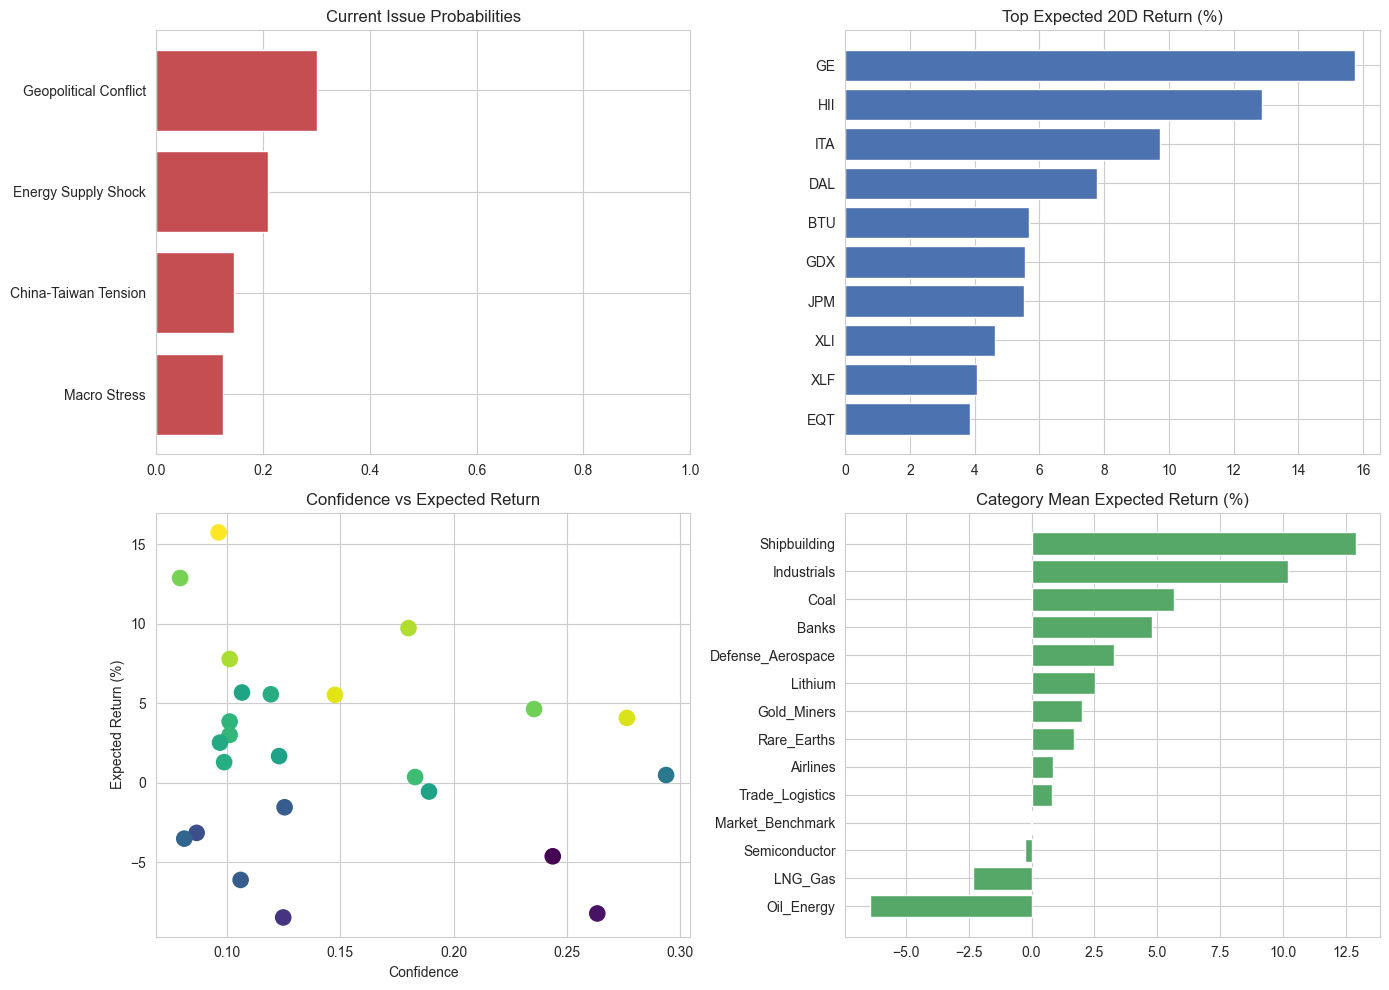

In [61]:
if len(df_predictions) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    t = df_threats.sort_values("Probability", ascending=True)
    ax.barh(t["Theme"], t["Probability"], color="#c44e52")
    ax.set_title("Current Issue Probabilities")
    ax.set_xlim(0, 1)

    ax = axes[0, 1]
    top = df_predictions.head(10).sort_values("Expected_Return_%", ascending=True)
    ax.barh(top["Stock"], top["Expected_Return_%"], color="#4c72b0")
    ax.set_title(f"Top Expected {PRIMARY_FORECAST_HORIZON}D Return (%)")

    ax = axes[1, 0]
    ax.scatter(df_predictions["Confidence"], df_predictions["Expected_Return_%"], c=df_predictions["Up_Probability"], cmap="viridis", s=120)
    ax.set_title("Confidence vs Expected Return")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Expected Return (%)")

    ax = axes[1, 1]
    cat = df_predictions.groupby("Category")["Expected_Return_%"].mean().sort_values()
    ax.barh(cat.index, cat.values, color="#55a868")
    ax.set_title("Category Mean Expected Return (%)")

    plt.tight_layout()
    plt.show()
else:
    print("No plot: predictions are empty.")


# 11. 최종 투자 추천


In [62]:
print("=" * 90)
print(f"Event-driven allocation view ({ANALYSIS_DATE:%Y-%m-%d}, primary_horizon={PRIMARY_FORECAST_HORIZON}D)")
print("=" * 90)

if len(df_predictions) == 0:
    print("Insufficient model output. Continue accumulating data and rerun.")
elif not pipeline_diagnostics.get("recommendation_ready", False):
    print("Recommendation gate is closed.")
    print(f"Reason -> news_history_days={pipeline_diagnostics.get('news_history_days', 0)}, quality_pass_count={pipeline_diagnostics.get('quality_pass_count', 0)}")
    print("Collect more daily news history or improve model quality before using ranked picks.")
else:
    picks = df_predictions[df_predictions["Quality_Pass"]].copy()
    picks = picks[picks["Confidence"] >= MIN_PREDICTION_CONFIDENCE].head(8)
    if picks.empty:
        picks = df_predictions[df_predictions["Quality_Pass"]].head(8)
    print("Top candidates:")
    print(picks[["Category_KR", "Asset_Name", "Stock", "Expected_Return_5D_%", "Expected_Return_20D_%", "Expected_Return_60D_%", "Up_Probability", "Confidence", "Oversold_Rebound_Score", "Quality_Pass"]].to_string(index=False))
    avg_ret = picks[f"Expected_Return_{PRIMARY_FORECAST_HORIZON}D_%"].mean()
    print(f"Average expected {PRIMARY_FORECAST_HORIZON}D return of picks: {avg_ret:.2f}%")
    print("\nRisk notes:")
    print("1) Ranking is centered on the 20D horizon but also shows 5D and 60D paths.")
    print("2) Oversold rebound score can elevate sharp event-driven selloffs with recovery potential.")
    print("3) Treat output as probabilistic signal, not financial advice.")


Event-driven allocation view (2026-03-24, primary_horizon=20D)
Recommendation gate is closed.
Reason -> news_history_days=38, quality_pass_count=0
Collect more daily news history or improve model quality before using ranked picks.


# 12. 머신러닝 기반 고급 분석


In [63]:
print("Advanced model diagnostics")
if len(df_model_eval) == 0:
    print("No diagnostics yet (not enough train rows per symbol).")
else:
    print(df_model_eval.head(12).to_string(index=False))
    print("\nModel quality distribution")

    # 새 버전 컬럼 우선
    if all(c in df_model_eval.columns for c in ["CV_MAE", "CV_R2", "CV_Up_Acc"]):
        print(df_model_eval[["CV_MAE", "CV_R2", "CV_Up_Acc", "Holdout_MAE", "Holdout_R2", "Holdout_Up_Acc"]].describe().round(3))
    # 구버전 호환
    elif all(c in df_model_eval.columns for c in ["MAE", "R2", "Up_Acc"]):
        print(df_model_eval[["MAE", "R2", "Up_Acc"]].describe().round(3))
    else:
        print("Unexpected columns in df_model_eval:")
        print(df_model_eval.columns.tolist())


Advanced model diagnostics
Stock Asset_Name        Category Category_KR  Rows_5D  CV_R2_5D  CV_MAE_5D  CV_Up_Acc_5D  Holdout_R2_5D  Holdout_MAE_5D  Holdout_Up_Acc_5D                                                                          Best_Params_5D  Rows_20D  CV_R2_20D  CV_MAE_20D  CV_Up_Acc_20D  Holdout_R2_20D  Holdout_MAE_20D  Holdout_Up_Acc_20D                                                                         Best_Params_20D  Rows_60D  CV_R2_60D  CV_MAE_60D  CV_Up_Acc_60D  Holdout_R2_60D  Holdout_MAE_60D  Holdout_Up_Acc_60D                                                                         Best_Params_60D  Quality_Pass  Rebound_Bonus  Primary_Horizon_Days
  XLE    에너지 ETF      Oil_Energy      석유/에너지      501 -0.016013   0.025005      0.621212      -2.496357        0.034465           0.445545   {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 300}       501  -0.018167    0.037503       0.660606       -2.896618         0.088664          

# 13. 종합 분석 결론


In [64]:
best_overall = df_predictions.iloc[0] if len(df_predictions) > 0 else None
best_qualified = df_predictions[df_predictions["Quality_Pass"]].iloc[0] if len(df_predictions) > 0 and df_predictions["Quality_Pass"].any() else None
summary_target = best_qualified if best_qualified is not None else best_overall

if summary_target is not None:
    msg = f"""
{'=' * 90}
FINAL SUMMARY
{'=' * 90}
- Confidence ({PRIMARY_FORECAST_HORIZON}D): {summary_target['Confidence']:.2%}
- Quality pass: {bool(summary_target['Quality_Pass'])}
- Top forecasted asset: {summary_target['Category_KR']} / {summary_target['Asset_Name']} [{summary_target['Stock']}]
- Current issue intensity (mean): {df_threats['Probability'].mean():.2f}
- Up probability ({PRIMARY_FORECAST_HORIZON}D): {summary_target['Up_Probability']:.2%}
- Expected 5D return: {summary_target.get('Expected_Return_5D_%', float('nan')):.2f}%
- Expected 20D return: {summary_target.get('Expected_Return_20D_%', float('nan')):.2f}%
- Expected 60D return: {summary_target.get('Expected_Return_60D_%', float('nan')):.2f}%
- Oversold rebound score: {summary_target.get('Oversold_Rebound_Score', 0.0):.3f}

Pipeline status:
- News master: {NEWS_MASTER_PATH}
- Price master: {PRICE_MASTER_PATH}
- News snapshot: {_latest_snapshot_path(NEWS_SNAPSHOT_DIR, 'news_history')}
- Price snapshot: {_latest_snapshot_path(PRICE_SNAPSHOT_DIR, 'price_history')}
- Feature rows: {len(df_features)}
- Model outputs: {len(df_predictions)}
- News-covered days in lookback: {pipeline_diagnostics.get('news_history_days', 0)}
- Recommendation ready: {pipeline_diagnostics.get('recommendation_ready', False)}
{'=' * 90}
"""
else:
    msg = f"""
{'=' * 90}
FINAL SUMMARY
{'=' * 90}
Not enough historical rows for robust per-symbol ML training yet.
Keep collecting data daily into the master history, then rerun this notebook.
{'=' * 90}
"""

print(msg)



FINAL SUMMARY
- Confidence (20D): 18.01%
- Quality pass: False
- Top forecasted asset: 방산/항공우주 / 미국 방산 ETF [ITA]
- Current issue intensity (mean): 0.20
- Up probability (20D): 82.09%
- Expected 5D return: 5.93%
- Expected 20D return: 9.72%
- Expected 60D return: 21.43%
- Oversold rebound score: 0.108

Pipeline status:
- News master: c:\Users\user\Documents\GitHub\GB_practicing\Stock_analysis\data\event_driven_stock_predictor\news_master_history.csv
- Price master: c:\Users\user\Documents\GitHub\GB_practicing\Stock_analysis\data\event_driven_stock_predictor\price_master_history.csv
- News snapshot: c:\Users\user\Documents\GitHub\GB_practicing\Stock_analysis\data\event_driven_stock_predictor\news_snapshots\news_history_20260324_022348.csv
- Price snapshot: c:\Users\user\Documents\GitHub\GB_practicing\Stock_analysis\data\event_driven_stock_predictor\price_snapshots\price_history_20260324_022348.csv
- Feature rows: 12024
- Model outputs: 24
- News-covered days in lookback: 38
- Recommenda

# 14. 데이터 커버리지 점검


In [65]:
print("Data coverage report")
print("=" * 90)

if 'df_news' in globals() and isinstance(df_news, pd.DataFrame) and len(df_news) > 0:
    news_dates = pd.to_datetime(df_news['date'], utc=True, errors='coerce').dropna()
    print("[News]")
    print(f"Rows: {len(df_news):,}")
    print(f"Date range: {news_dates.min()} -> {news_dates.max()}")
    print(f"Unique sources: {df_news['source'].nunique() if 'source' in df_news.columns else 0}")
else:
    print("[News]")
    print("No news data available.")

print("\n" + "-" * 90)

if 'df_prices' in globals() and isinstance(df_prices, pd.DataFrame) and len(df_prices) > 0:
    ptmp = df_prices.copy()
    ptmp['date'] = pd.to_datetime(ptmp['date'], utc=True, errors='coerce')
    ptmp = ptmp.dropna(subset=['date'])

    summary = (
        ptmp.groupby(['symbol', 'category'], as_index=False)
        .agg(
            rows=('date', 'count'),
            first_date=('date', 'min'),
            last_date=('date', 'max'),
            last_close=('close', 'last')
        )
        .sort_values(['category', 'symbol'])
        .reset_index(drop=True)
    )
    summary['calendar_days'] = (summary['last_date'] - summary['first_date']).dt.days

    print("[Prices by symbol]")
    print(f"Total rows: {len(ptmp):,}")
    print(f"Tracked symbols: {summary['symbol'].nunique()}")
    print(f"Overall date range: {ptmp['date'].min()} -> {ptmp['date'].max()}")

    print("\nCoverage table (head 30):")
    print(summary[['symbol', 'category', 'rows', 'first_date', 'last_date', 'calendar_days', 'last_close']].head(30).to_string(index=False))

    print("\nCoverage stats:")
    print(summary['rows'].describe().round(1).to_string())

    low_cov = summary[summary['rows'] < 200]
    if len(low_cov) > 0:
        print("\nSymbols with low coverage (<200 rows):")
        print(low_cov[['symbol', 'category', 'rows', 'first_date', 'last_date']].to_string(index=False))
else:
    print("[Prices]")
    print("No price data available.")

print("=" * 90)


Data coverage report
[News]
Rows: 1,728
Date range: 2026-02-10 15:59:00+00:00 -> 2026-03-23 14:23:00+00:00
Unique sources: 271

------------------------------------------------------------------------------------------
[Prices by symbol]
Total rows: 12,024
Tracked symbols: 24
Overall date range: 2024-03-22 00:00:00+00:00 -> 2026-03-23 00:00:00+00:00

Coverage table (head 30):
symbol          category  rows                first_date                 last_date  calendar_days  last_close
   DAL          Airlines   501 2024-03-22 00:00:00+00:00 2026-03-23 00:00:00+00:00            731   65.129997
  JETS          Airlines   501 2024-03-22 00:00:00+00:00 2026-03-23 00:00:00+00:00            731   24.930000
   JPM             Banks   501 2024-03-22 00:00:00+00:00 2026-03-23 00:00:00+00:00            731  289.910004
   XLF             Banks   501 2024-03-22 00:00:00+00:00 2026-03-23 00:00:00+00:00            731   49.270000
   BTU              Coal   501 2024-03-22 00:00:00+00:00 2026-03-23 00: